In [10]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
neuromusic_avocado_prices_path = kagglehub.dataset_download('neuromusic/avocado-prices')

print('Data source import complete.')


Using Colab cache for faster access to the 'avocado-prices' dataset.
Data source import complete.


In [11]:
# --- Notebook Theme (codes from @vivek468) ---
from IPython.core.display import display, HTML, Javascript

color_map = ['#568203', '#719C27']

prompt = color_map[-1]
main_color = color_map[0]
strong_main_color = color_map[1]
custom_colors = [strong_main_color, main_color]

css_file = '''
div #notebook {
background-color: white;
line-height: 20px;
}

#notebook-container {
%s
margin-top: 2em;
padding-top: 2em;
border-top: 4px solid %s;
-webkit-box-shadow: 0px 0px 8px 2px rgba(224, 212, 226, 0.5);
    box-shadow: 0px 0px 8px 2px rgba(224, 212, 226, 0.5);
}

div .input {
margin-bottom: 1em;
}

.rendered_html h1, .rendered_html h2, .rendered_html h3, .rendered_html h4, .rendered_html h5, .rendered_html h6 {
color: %s;
font-weight: 600;
}

div.input_area {
border: none;
    background-color: %s;
    border-top: 2px solid %s;
}

div.input_prompt {
color: %s;
}

div.output_prompt {
color: %s;
}

div.cell.selected:before, div.cell.selected.jupyter-soft-selected:before {
background: %s;
}

div.cell.selected, div.cell.selected.jupyter-soft-selected {
    border-color: %s;
}

.edit_mode div.cell.selected:before {
background: %s;
}

.edit_mode div.cell.selected {
border-color: %s;

}
'''

def to_rgb(h):
    return tuple(int(h[i:i+2], 16) for i in [0, 2, 4])

main_color_rgba = 'rgba(%s, %s, %s, 0.1)' % (to_rgb(main_color[1:]))
open('notebook.css', 'w').write(css_file % ('width: 95%;', main_color, main_color, main_color_rgba, main_color,  main_color, prompt, main_color, main_color, main_color, main_color))

def nb():
    return HTML("<style>" + open("notebook.css", "r").read() + "</style>")
nb()

.: PyCaret 대체 파이프라인 구축 시작 :.
Train target 분할 완료: (14599, 12) (14599,)
Test target 분할 완료: (3650, 12) (3650,)
****************************************
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2184
[LightGBM] [Info] Number of data points in the train set: 14599, number of used features: 80
[LightGBM] [Info] Start training from score 1.405350


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


.: 모델 성능 평가 결과 (R2 Score 기준 정렬) :.


,Model,Train R2,Test R2
0,Extra Tree Regressor,1.000000,0.917764
1,Random Forest Regressor,0.985096,0.880814
2,Light Gradient Boosting Machine,0.901756,0.865095


/tmp/ipykernel_23003/2021907322.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(all_features)[indices], palette='viridis')


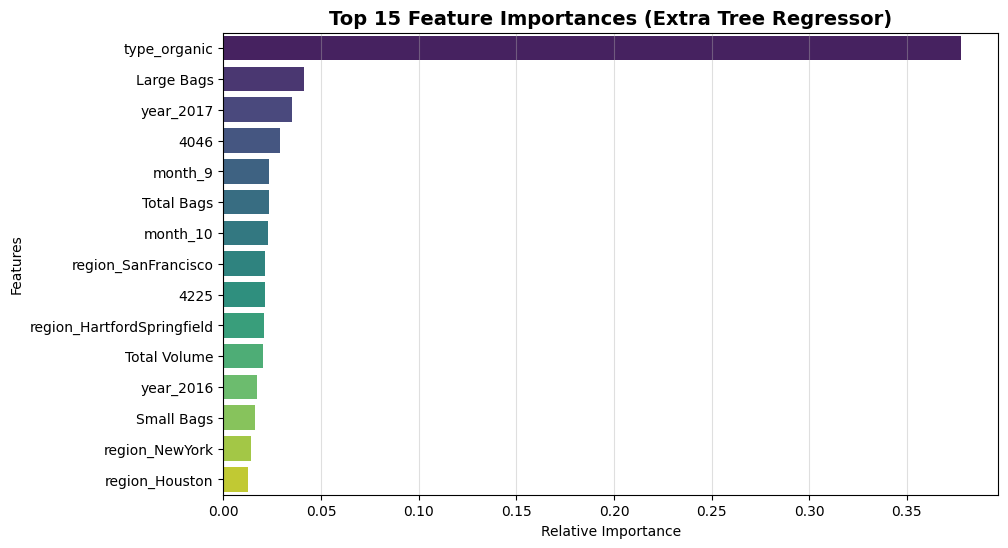

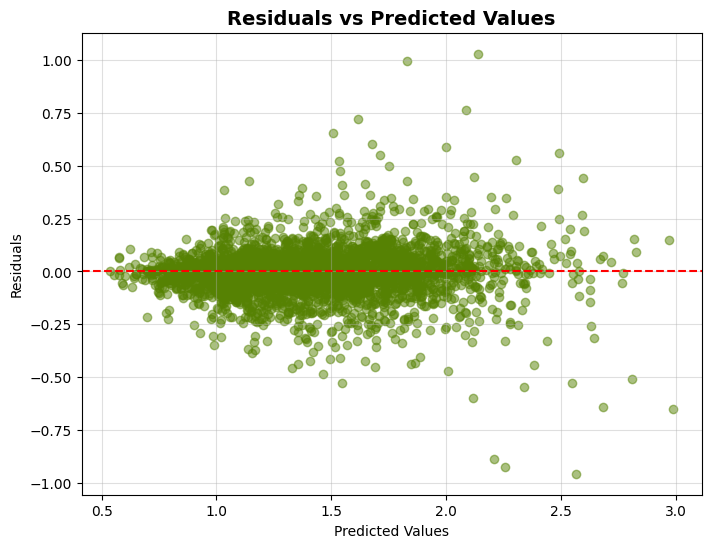

⭐ 중요: Extra Tree Regressor 모델 학습 및 평가 완료! ⭐


In [12]:
# --- Importing Essential ML Libraries ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# <div style="font-family: Trebuchet MS; background-color: #568203; color: #FFFFFF; padding: 12px; line-height: 1.5;">8. | Data Preprocessing & Modeling ⚙</div>

print('\033[92m\033[1m'+'.: PyCaret 대체 파이프라인 구축 시작 :.'+'\033[0m')

# --- Reading Dataset --- (added from a83b9027 to ensure 'ds' is defined)
ds = pd.read_csv('/content/avocado.csv')

# --- Change `Date` Format to 'datetime' --- (added from e7118636)
ds.Date = pd.to_datetime(ds.Date)

# --- Extracting Month Number from `Date`  --- (added from e7118636)
ds['month'] = pd.DatetimeIndex(ds['Date']).month

# --- 1. 데이터 분리 (Target과 Features) ---
# 쓸모없는 인덱스 컬럼(Unnamed: 0)과 이미 month로 추출한 Date 컬럼은 제거합니다.
if 'Unnamed: 0' in ds.columns:
    ds = ds.drop(columns=['Unnamed: 0'])

X = ds.drop(columns=['AveragePrice', 'Date'])
y = ds['AveragePrice']

# --- 2. 범주형 및 수치형 변수 지정 ---
# PyCaret에서 지정했던 것과 동일하게 설정
categorical_features = ['type', 'year', 'region', 'month']
numeric_features = [col for col in X.columns if col not in categorical_features]

# --- 3. 전처리 파이프라인 구축 (ColumnTransformer) ---
# 수치형 변수: RobustScaler (이상치에 강함)
# 범주형 변수: OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# --- 4. Train / Test Split (80% / 20%) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

print('Train target 분할 완료:', X_train.shape, y_train.shape)
print('Test target 분할 완료:', X_test.shape, y_test.shape)
print('\033[92m'+'*' * 40+'\033[0m')


# <div style="font-family: Trebuchet MS; background-color: #8CB743; color: #FFFFFF; padding: 12px; line-height: 1.5;">8.1 | Model Training & Evaluation 🏭</div>

# --- 5. 평가할 앙상블 모델들 정의 ---
# PyCaret에서 성능이 가장 좋았던 Top 3 모델을 그대로 구현합니다.
models = {
    'Extra Tree Regressor': ExtraTreesRegressor(random_state=123, n_jobs=-1),
    'Random Forest Regressor': RandomForestRegressor(random_state=123, n_jobs=-1),
    'Light Gradient Boosting Machine': LGBMRegressor(random_state=123, n_jobs=-1)
}

trained_models = {}
results = []

# --- 6. 모델 학습 및 R2 Score 비교 ---
for model_name, model in models.items():
    # 전처리와 모델을 하나의 파이프라인으로 연결
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', model)])

    # 모델 학습
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    # 예측 수행
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # 성능 평가 (R2 Score)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        'Model': model_name,
        'Train R2': train_r2,
        'Test R2': test_r2
    })

# 결과 출력
results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
print('\033[92m\033[1m'+'.: 모델 성능 평가 결과 (R2 Score 기준 정렬) :.'+'\033[0m')
display(results_df.style.background_gradient(cmap='Greens').set_properties(**{'font-family': 'Segoe UI'}))


# <div style="font-family: Trebuchet MS; background-color: #8CB743; color: #FFFFFF; padding: 12px; line-height: 1.5;">8.2 | Finalize Best Model & Visualization 🏁</div>

# --- 7. 가장 성능이 좋은 모델로 Feature Importance 시각화 (Extra Tree) ---
best_model_name = results_df.iloc[0]['Model']
best_pipeline = trained_models[best_model_name]
best_model = best_pipeline.named_steps['model']

# OneHotEncoder를 거친 후의 컬럼 이름 가져오기
cat_encoder = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features)
all_features = numeric_features + list(encoded_cat_cols)

# Feature Importance 추출 (상위 15개)
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.title(f'Top 15 Feature Importances ({best_model_name})', fontweight='bold', fontsize=14)
sns.barplot(x=importances[indices], y=np.array(all_features)[indices], palette='viridis')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.grid(axis='x', alpha=0.4)
plt.show()

# --- 8. 예측 오차 (Residual) 산점도 시각화 ---
y_test_pred = best_pipeline.predict(X_test)
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, alpha=0.5, color='#568203')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(alpha=0.4)
plt.show()

print('='*80)
print(f'⭐ 중요: {best_model_name} 모델 학습 및 평가 완료! ⭐')
print('='*80)

In [13]:
# Install pycaret if not already installed
!pip install pycaret

# NOTE: If you encounter 'ModuleNotFoundError' after installation, please restart your runtime (Runtime -> Restart runtime) and then run the cells again.

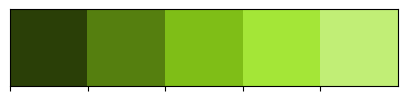

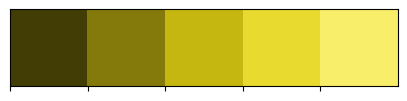

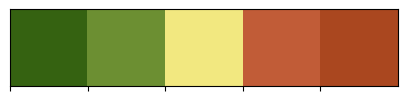

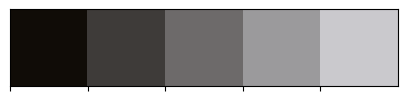

In [14]:
# --- Create List of Color Palletes ---
olive_grad = ['#2A3F07', '#557F0F', '#7FBE17', '#A4E637', '#C1EE76']
yellow_grad = ['#413D05', '#837A0B', '#C5B710', '#E8DA2E', '#F9EE6A']
color_mix = ['#356211', '#6C8F32', '#F2E880', '#C15C37', '#AA471F']
black_grad = ['#100C07', '#3E3B39', '#6D6A6A', '#9B9A9C', '#CAC9CD']

# --- Plot Color Palletes --
sns.palplot(olive_grad)
sns.palplot(yellow_grad)
sns.palplot(color_mix)
sns.palplot(black_grad)

In [15]:
# --- Reading Dataset ---
ds = pd.read_csv('avocado.csv')
ds.head().style.background_gradient(cmap='Greens').set_properties(**{'font-family': 'Segoe UI'}).hide(axis='index')

Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.330000,64236.620000,1036.740000,54454.850000,48.160000,8696.870000,8603.620000,93.250000,0.000000,conventional,2015,Albany
1,2015-12-20,1.350000,54876.980000,674.280000,44638.810000,58.330000,9505.560000,9408.070000,97.490000,0.000000,conventional,2015,Albany
2,2015-12-13,0.930000,118220.220000,794.700000,109149.670000,130.500000,8145.350000,8042.210000,103.140000,0.000000,conventional,2015,Albany
3,2015-12-06,1.080000,78992.150000,1132.000000,71976.410000,72.580000,5811.160000,5677.400000,133.760000,0.000000,conventional,2015,Albany
4,2015-11-29,1.280000,51039.600000,941.480000,43838.390000,75.780000,6183.950000,5986.260000,197.690000,0.000000,conventional,2015,Albany


In [16]:
# --- Print Dataset Info ---
print('\033[92m\033[1m'+'.: Imported Dataset Info :.'+'\033[0m')
print('\033[92m*' * 30+'\033[0m')
print('Total Rows:'+'\033[92m\033[1m', ds.shape[0])
print('\033[0m'+'Total Columns:'+'\033[92m\033[1m', ds.shape[1])
print('\033[0m\033[92m'+'*' * 30+'\033[0m')
print('\n')

# --- Print Dataset Detail ---
print('\033[92m\033[1m'+'.: Dataset Details :.'+'\033[0m')
print('\033[0m\033[92m'+'*' * 30+'\033[0m')
ds.info(memory_usage = False)

.: Imported Dataset Info :.
******************************
Total Rows: 18249
Total Columns: 14
******************************


.: Dataset Details :.
******************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), in

****************************************
.: Total Avocado based on each Type :.
****************************************


/tmp/ipykernel_23003/4190262578.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'type', data = ds, palette = colors, order = order, edgecolor = black_grad[2], alpha = 0.85)


,count
type,
conventional,9126
organic,9123


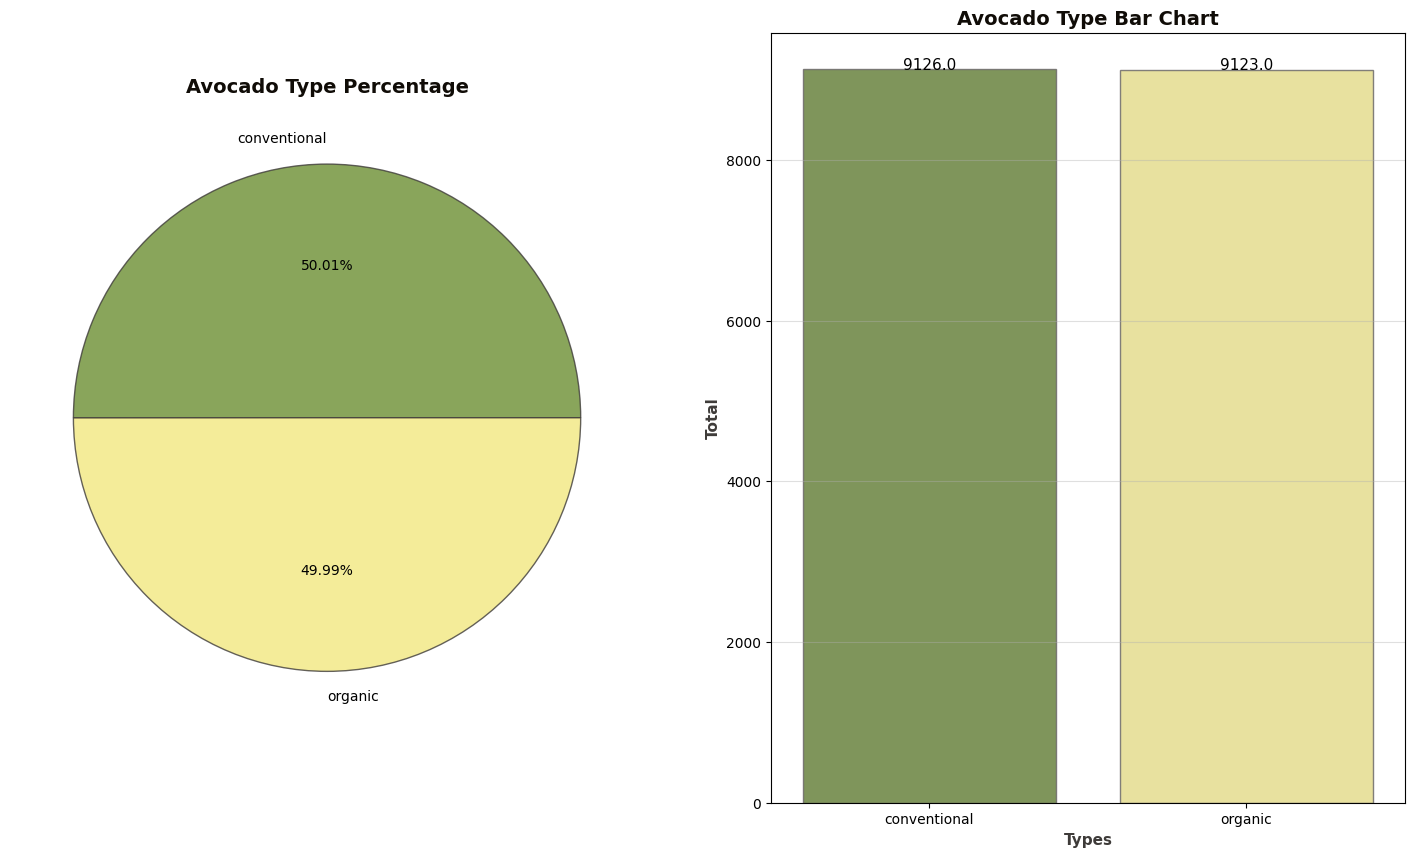

In [17]:
# --- Colors and Labels (Null Values Dropped) ---
colors = color_mix[1:3]
labels = ds['type'].dropna().unique()
order = ds['type'].value_counts().index

# --- Size for Both Figures ---
plt.figure(figsize=(18, 10))

# --- Pie Chart ---
plt.subplot(1, 2, 1)
plt.title('Avocado Type Percentage', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif',
          color = black_grad[0])
plt.pie(ds['type'].value_counts(), labels = order, colors = colors,
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%')

# --- Bar Chart ---
countplt = plt.subplot(1, 2, 2)
plt.title('Avocado Type Bar Chart', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
ax = sns.countplot(x = 'type', data = ds, palette = colors, order = order, edgecolor = black_grad[2], alpha = 0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2, rect.get_height()+0.75,rect.get_height(), horizontalalignment = 'center',
             fontsize = 11)

plt.xlabel('Types', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
countplt

# --- Count Categorical Labels w/out Dropping Null Walues ---
print('\033[92m'+'*' * 40)
print('\033[92m\033[1m'+'.: Total Avocado based on each Type :.'+'\033[0m')
print('\033[92m'+'*' * 40+'\033[0m')
ds.type.value_counts(dropna=False)

***********************************
.: Total Avocado based on Year :.
***********************************


/tmp/ipykernel_23003/2237389726.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'year', data = ds, palette = colors, order = order, edgecolor = black_grad[2], alpha = 0.85)
/tmp/ipykernel_23003/2237389726.py:18: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.countplot(x = 'year', data = ds, palette = colors, order = order, edgecolor = black_grad[2], alpha = 0.85)


,count
year,
2017,5722
2016,5616
2015,5615
2018,1296


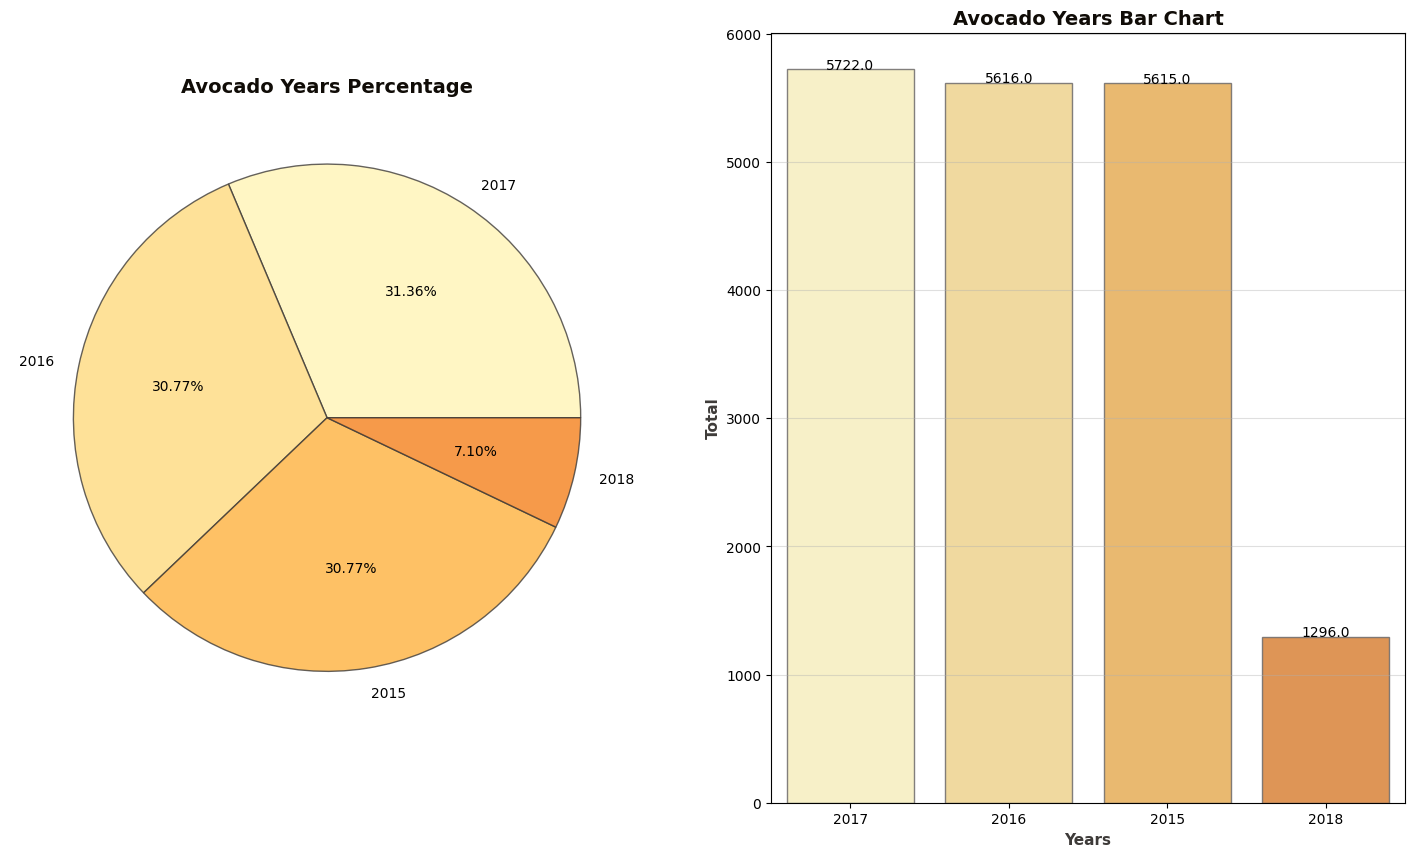

In [18]:
# --- Colors and Labels (Null Values Dropped) ---
colors = sns.color_palette('YlOrBr')
labels = ds['year'].dropna().unique()
order = ds['year'].value_counts().index

# --- Size for Both Figures ---
plt.figure(figsize=(18,10))

# --- Pie Chart ---
plt.subplot(1,2,1)
plt.title('Avocado Years Percentage', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
plt.pie(ds['year'].value_counts(), labels = order, colors = colors,
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%')

# --- Bar Chart ---
countplt = plt.subplot(1,2,2)
plt.title('Avocado Years Bar Chart', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
ax = sns.countplot(x = 'year', data = ds, palette = colors, order = order, edgecolor = black_grad[2], alpha = 0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2, rect.get_height()+0.75,rect.get_height(), horizontalalignment = 'center',
             fontsize = 10)

plt.xlabel('Years', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
countplt

# --- Count Categorical Labels w/out Dropping Null Walues ---
print('\033[92m'+'*' * 35)
print('\033[92m\033[1m'+'.: Total Avocado based on Year :.'+'\033[0m')
print('\033[92m'+'*' * 35+'\033[0m')
ds.year.value_counts(dropna=False)

In [19]:
# --- Count Categorical Labels w/Out Dropping Null Walues ---
print('\033[92m'+'*' * 38)
print('\033[92m\033[1m'+'.: Total Avocado based on Regions :.'+'\033[0m')
print('\033[92m'+'*' * 38)
ds.region.value_counts(dropna=False)

**************************************
.: Total Avocado based on Regions :.
**************************************


,count
region,
Albany,338
Atlanta,338
BaltimoreWashington,338
Boise,338
Boston,338
BuffaloRochester,338
California,338
Charlotte,338
Chicago,338


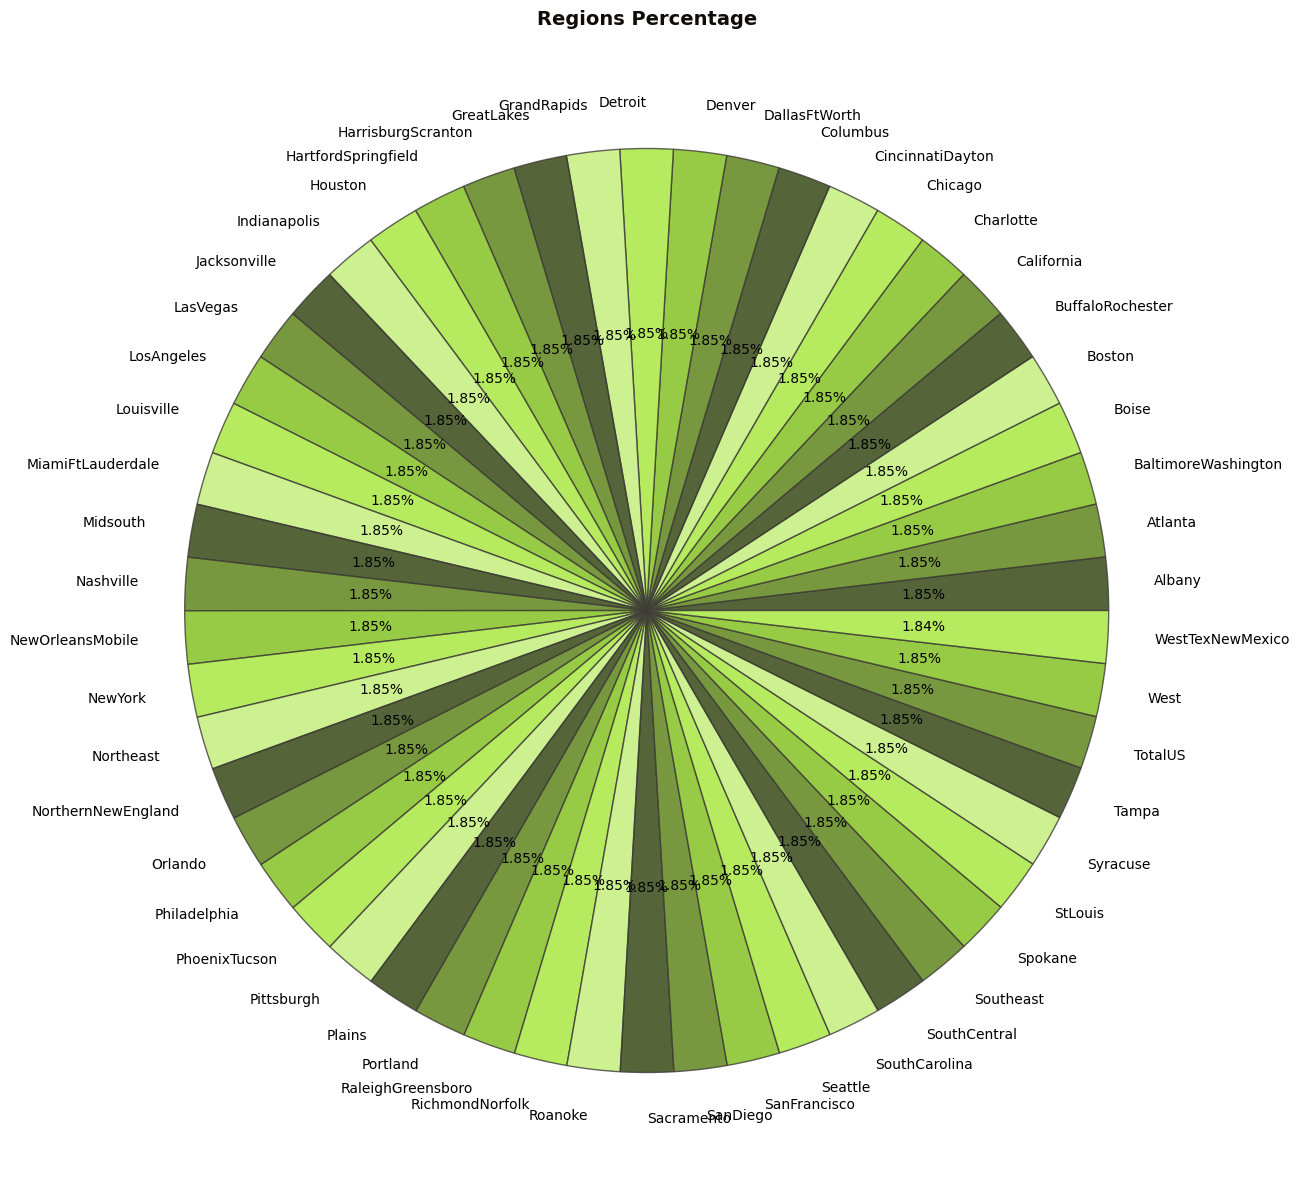

In [20]:
# --- Colors and Labels (Null Values Dropped) ---
colors = olive_grad[0:5]
labels = ds['region'].dropna().unique()
order = ds['region'].value_counts().index

# --- Pie Chart ---
plt.figure(figsize = (15, 15))
plt.title('Regions Percentage', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
plt.pie(ds['region'].value_counts(), labels = order, colors = colors,
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%');

/tmp/ipykernel_23003/395180684.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y = 'region', data = ds, order = order, palette = colors, edgecolor = black_grad[2], alpha = 0.85)
/tmp/ipykernel_23003/395180684.py:4: UserWarning: 
The palette list has fewer values (5) than needed (54) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(y = 'region', data = ds, order = order, palette = colors, edgecolor = black_grad[2], alpha = 0.85)


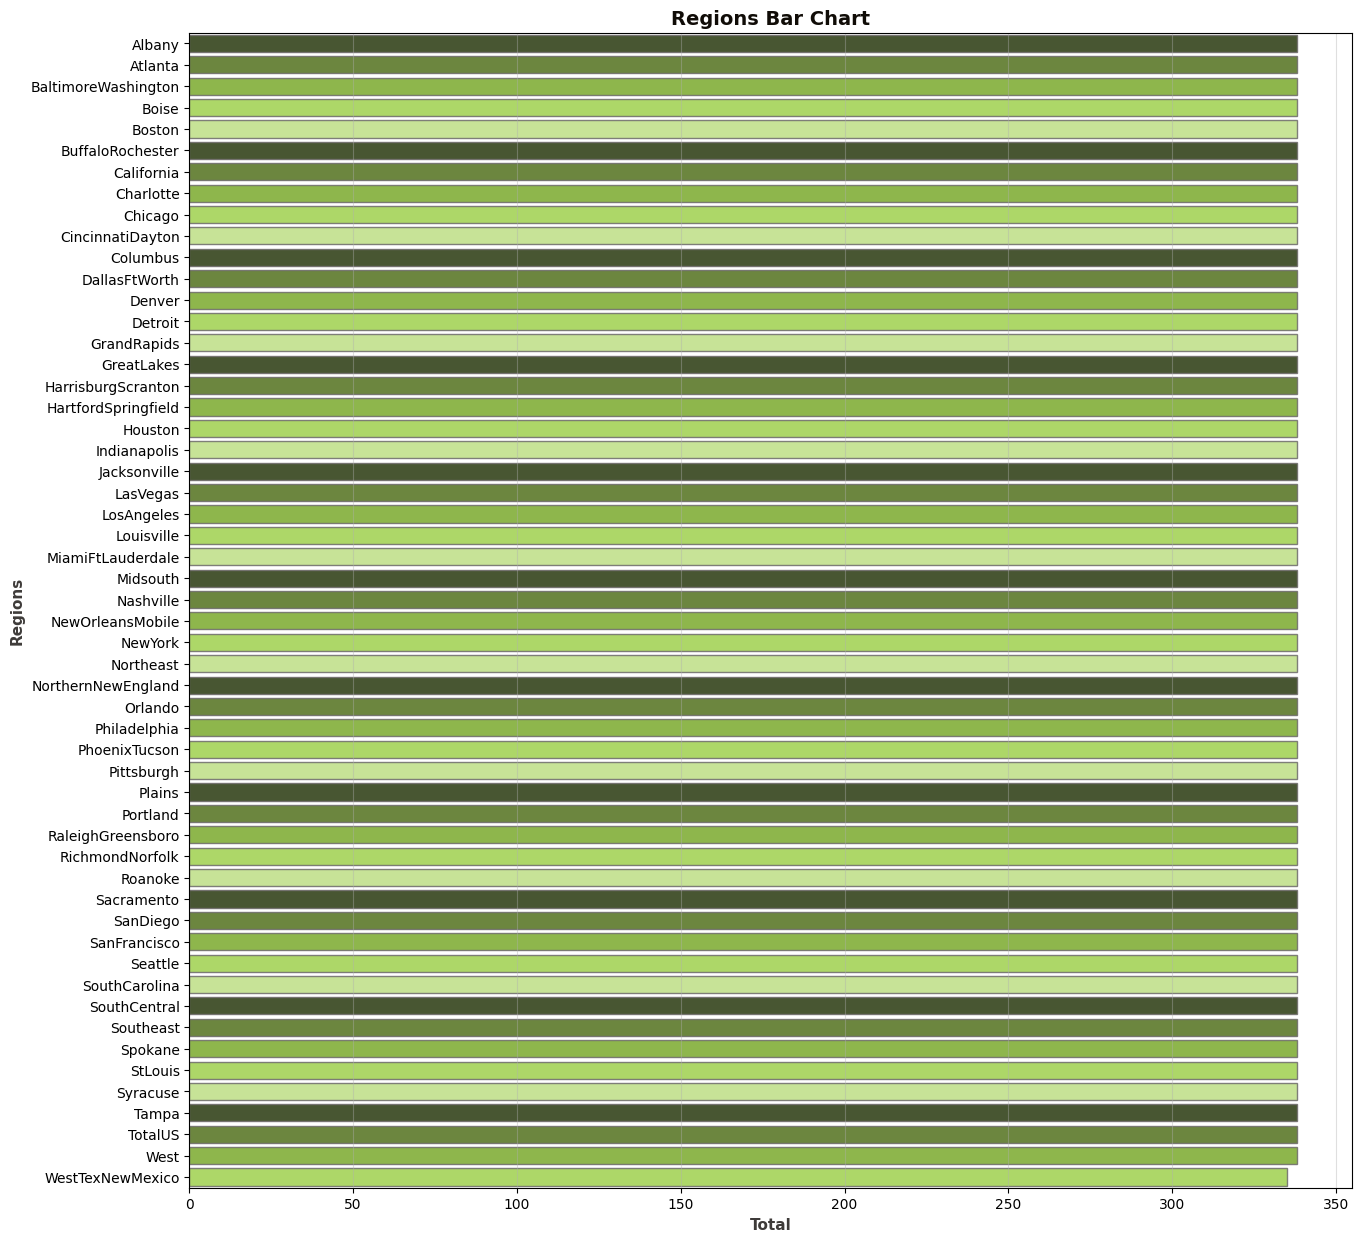

In [21]:
# --- Bar Chart ---
plt.figure(figsize = (15, 15))
plt.title('Regions Bar Chart', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
sns.countplot(y = 'region', data = ds, order = order, palette = colors, edgecolor = black_grad[2], alpha = 0.85)
plt.xlabel('Total', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Regions', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'x', alpha = 0.4);

In [22]:
# --- Descriptive Statistics ---
ds[['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags',
    'XLarge Bags']].describe().T.style.background_gradient(cmap='YlOrBr').set_properties(**{'font-family': 'Segoe UI'})

,count,mean,std,min,25%,50%,75%,max
AveragePrice,18249.000000,1.405978,0.402677,0.440000,1.100000,1.370000,1.660000,3.250000
Total Volume,18249.000000,850644.013009,3453545.355399,84.560000,10838.580000,107376.760000,432962.290000,62505646.520000
4046,18249.000000,293008.424531,1264989.081763,0.000000,854.070000,8645.300000,111020.200000,22743616.170000
4225,18249.000000,295154.568356,1204120.401135,0.000000,3008.780000,29061.020000,150206.860000,20470572.610000
4770,18249.000000,22839.735993,107464.068435,0.000000,0.000000,184.990000,6243.420000,2546439.110000
Total Bags,18249.000000,239639.202060,986242.399216,0.000000,5088.640000,39743.830000,110783.370000,19373134.370000
Small Bags,18249.000000,182194.686696,746178.514962,0.000000,2849.420000,26362.820000,83337.670000,13384586.800000
Large Bags,18249.000000,54338.088145,243965.964547,0.000000,127.470000,2647.710000,22029.250000,5719096.610000
XLarge Bags,18249.000000,3106.426507,17692.894652,0.000000,0.000000,0.000000,132.500000,551693.650000


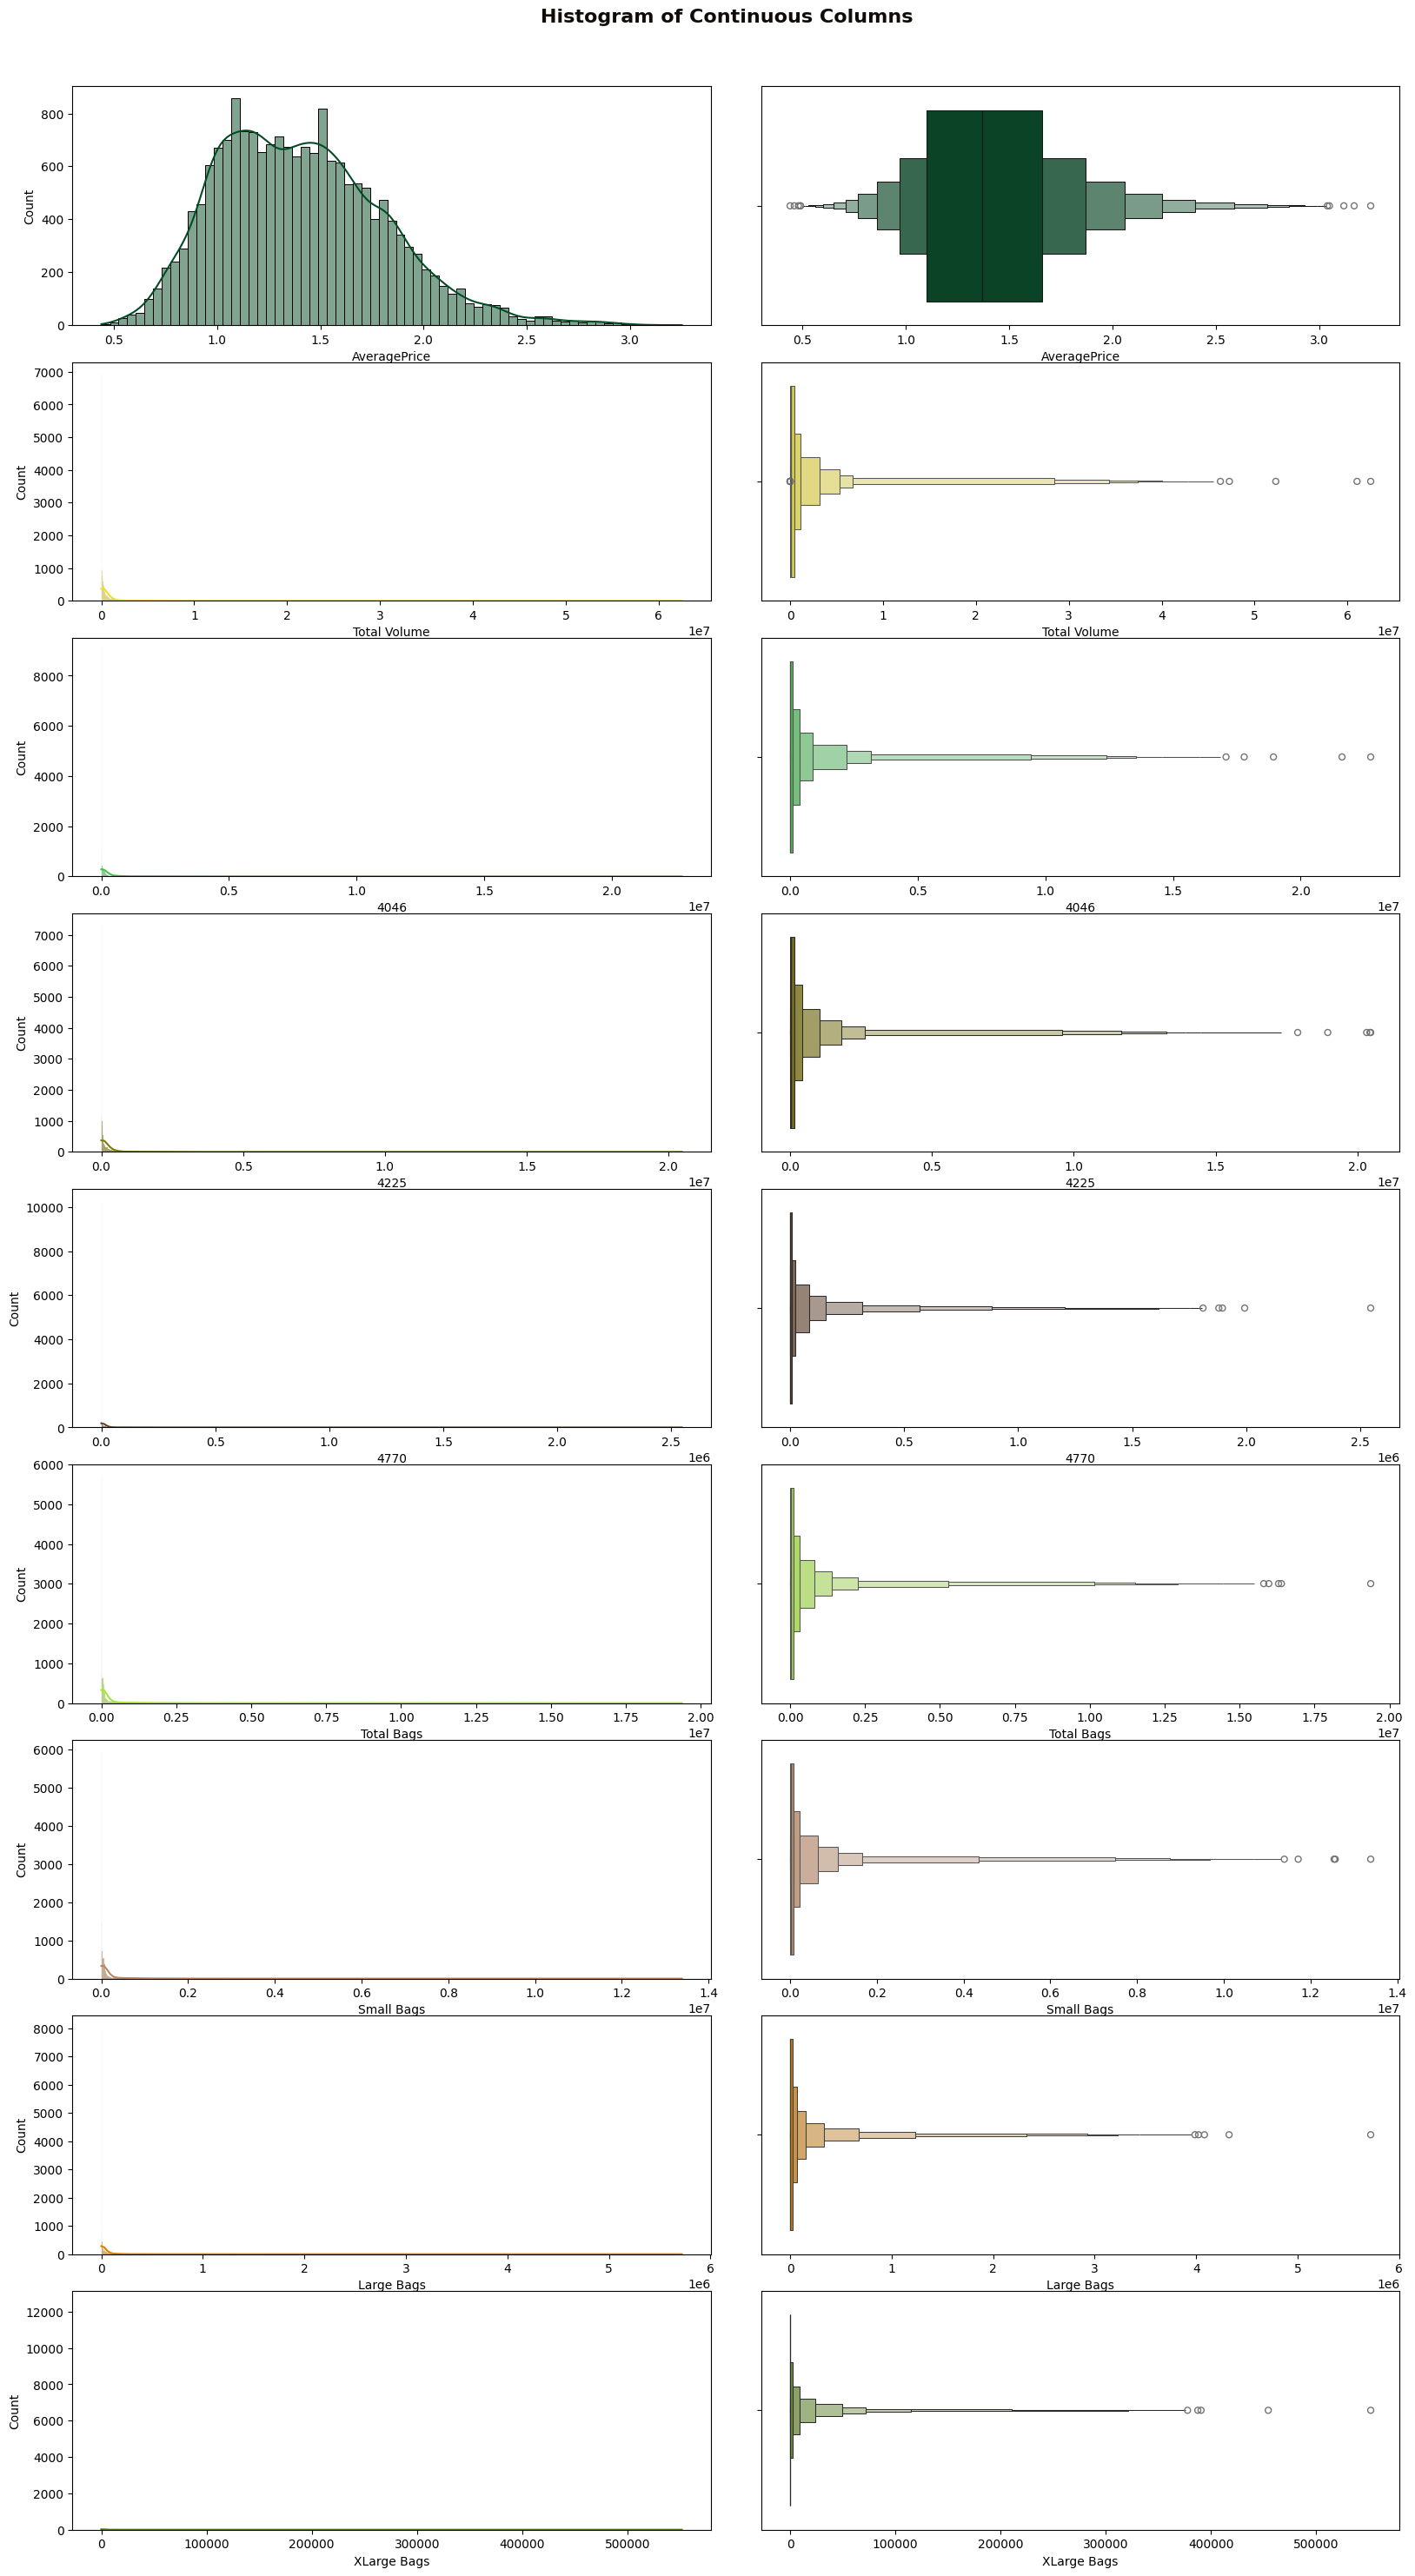

In [23]:
# --- Plot Size ---
fig, axs = plt.subplots(9, 2, figsize = (16, 30))

# --- General Title ---
fig.tight_layout()
fig.subplots_adjust(top = 0.95)
fig.suptitle('Histogram of Continuous Columns', fontweight = 'bold', fontsize = 16, fontfamily = 'sans-serif',
             color = black_grad[0])

# --- Continuous Variables (Row 1) ---
sns.histplot(data = ds, x = 'AveragePrice', kde = True, ax = axs[0, 0], color = '#004D25')
sns.boxenplot(data = ds, x = 'AveragePrice', ax = axs[0, 1], color = '#004D25')

# --- Continuous Variables (Row 2) ---
sns.histplot(data = ds, x = 'Total Volume', kde = True, ax = axs[1, 0], color = '#EDDE30')
sns.boxenplot(data = ds, x = 'Total Volume', ax = axs[1, 1], color = '#EDDE30')

# --- Continuous Variables (Row 3) ---
sns.histplot(data = ds, x='4046', kde = True, ax = axs[2, 0], color = '#48BF53')
sns.boxenplot(data = ds, x = '4046', ax = axs[2, 1], color = '#48BF53')

# --- Continuous Variables (Row 4) ---
sns.histplot(data = ds, x = '4225', kde = True, ax = axs[3, 0], color = '#837A0B')
sns.boxenplot(data = ds, x = '4225', ax = axs[3, 1], color = '#837A0B')

# --- Continuous Variables (Row 5) ---
sns.histplot(data = ds, x = '4770', kde = True, ax = axs[4, 0], color = '#664228')
sns.boxenplot(data = ds, x = '4770', ax = axs[4, 1], color = '#664228')

# --- Continuous Variables (Row 6) ---
sns.histplot(data = ds, x = 'Total Bags', kde = True, ax = axs[5, 0], color = '#A4E637')
sns.boxenplot(data = ds, x = 'Total Bags', ax = axs[5, 1], color = '#A4E637')

# --- Continuous Variables (Row 7) ---
sns.histplot(data = ds, x = 'Small Bags', kde = True, ax = axs[6, 0], color = '#BF865D')
sns.boxenplot(data = ds, x = 'Small Bags', ax = axs[6, 1], color = '#BF865D')

# --- Continuous Variables (Row 8) ---
sns.histplot(data = ds, x = 'Large Bags', kde = True, ax = axs[7, 0], color = '#D98000')
sns.boxenplot(data = ds, x = 'Large Bags', ax = axs[7, 1], color = '#D98000')

# --- Continuous Variables (Row 9) ---
sns.histplot(data = ds, x = 'XLarge Bags', kde = True, ax = axs[8, 0], color = '#557F0F')
sns.boxenplot(data = ds, x = 'XLarge Bags', ax = axs[8, 1], color = '#557F0F');

In [24]:
# --- Skewness of Continuous Variables ---
print('\033[92m\033[1m'+'.: Continuous Columns Skewness :.'+'\033[0m')
print('\033[92m*' * 34+'\033[0m')
ds[['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags',
    'XLarge Bags']].skew(axis = 0, skipna = True)

.: Continuous Columns Skewness :.
**********************************


,0
AveragePrice,0.580303
Total Volume,9.007687
4046,8.648220
4225,8.942466
4770,10.159396
Total Bags,9.756072
Small Bags,9.540660
Large Bags,9.796455
XLarge Bags,13.139751


In [25]:
# --- Kurtoisis of Continuous Variables ---
print('\033[92m\033[1m'+'.: Continuous Columns Kurtosis :.'+'\033[0m')
print('\033[92m*' * 34+'\033[0m')
ds[['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags',
    'XLarge Bags']].kurt(axis = 0, skipna = True)

.: Continuous Columns Kurtosis :.
**********************************


,0
AveragePrice,0.325196
Total Volume,92.104458
4046,86.809113
4225,91.949022
4770,132.563441
Total Bags,112.272156
Small Bags,107.012885
Large Bags,117.999481
XLarge Bags,233.602612


/tmp/ipykernel_23003/3293074147.py:5: FutureWarning: The provided callable <function mean at 0x7cef045f9760> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  eda0 = edaf_grouped_by_region.aggregate({'Total Volume': np.mean}).sort_values(by = 'Total Volume',
/tmp/ipykernel_23003/3293074147.py:11: FutureWarning: The provided callable <function mean at 0x7cef045f9760> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  eda1 = edaf_grouped_by_region.aggregate({'Total Volume': np.mean}).sort_values(by = 'Total Volume',
/tmp/ipykernel_23003/3293074147.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_left 

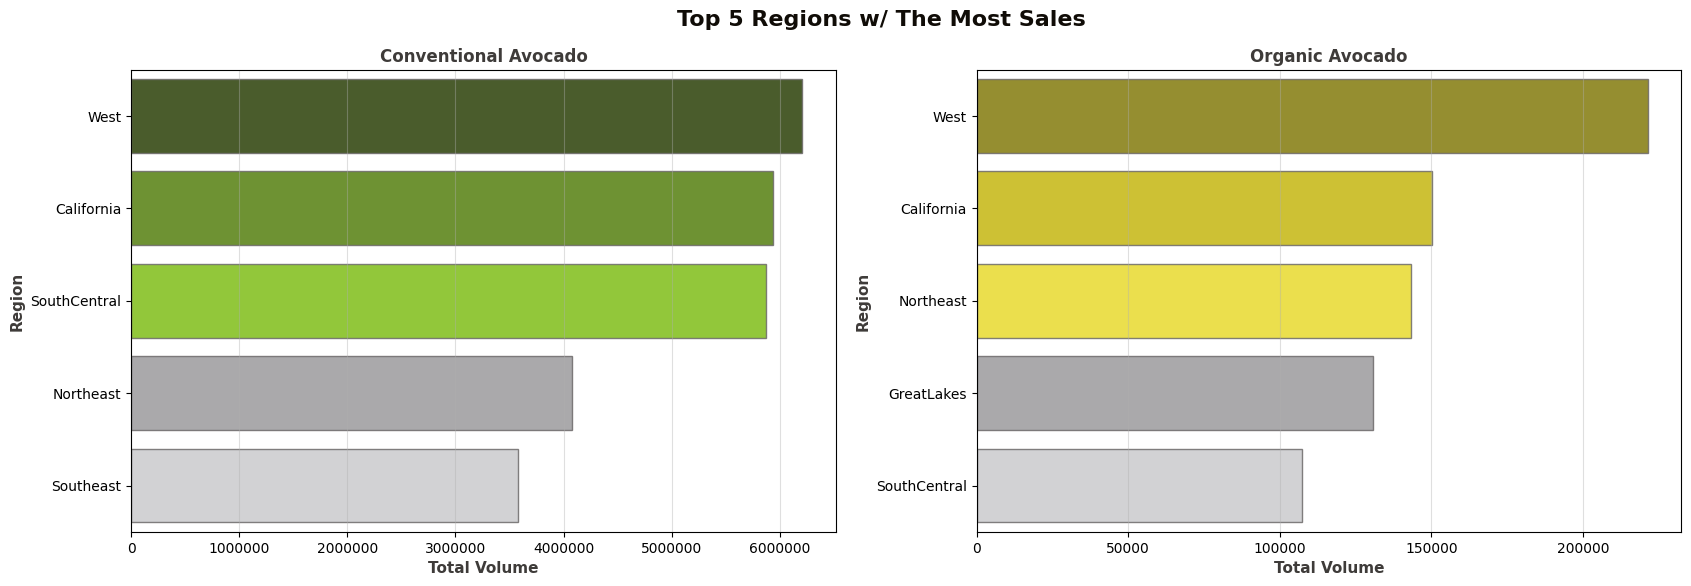

In [26]:
# --- Create New Dataframes based on Type ---
eda0 = ds[['region', 'Total Volume']][ds.type == 'conventional']
eda0 = eda0[eda0['region'] != 'TotalUS']
edaf_grouped_by_region = eda0.groupby(['region'])
eda0 = edaf_grouped_by_region.aggregate({'Total Volume': np.mean}).sort_values(by = 'Total Volume',
                                                                                 ascending = False).iloc[:5]

eda1 = ds[['region', 'Total Volume']][ds.type == 'organic']
eda1 = eda1[eda1['region'] != 'TotalUS']
edaf_grouped_by_region = eda1.groupby(['region'])
eda1 = edaf_grouped_by_region.aggregate({'Total Volume': np.mean}).sort_values(by = 'Total Volume',
                                                                                 ascending = False).iloc[:5]

# --- General Settings of Bar Charts ---
fig, ax = plt.subplots(1, 2, figsize = (20, 6))
fig.suptitle('Top 5 Regions w/ The Most Sales', fontweight = 'heavy', fontsize = 16, fontfamily = 'sans-serif',
             color = black_grad[0])

# --- Bar Chart Left ---
plt.subplot(1, 2, 1)
plt.title('Conventional Avocado', fontweight = 'bold', fontsize = 12, fontfamily = 'sans-serif', color = black_grad[1])
bar_left = sns.barplot(x='Total Volume', y = eda0.index, data = eda0, palette = black_grad, edgecolor = black_grad[2],
                       alpha = 0.85)
bar_left.patches[0].set_facecolor(olive_grad[0])
bar_left.patches[1].set_facecolor(olive_grad[1])
bar_left.patches[2].set_facecolor(olive_grad[2])
plt.xlabel('Total Volume', fontweight='bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Region', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0)
plt.grid(axis = 'x', alpha = 0.4)
plt.ticklabel_format(style = 'plain', axis = 'x')

# --- Bar Chart Right ---
plt.subplot(1, 2, 2)
plt.title('Organic Avocado', fontweight = 'bold', fontsize = 12, fontfamily = 'sans-serif', color = black_grad[1])
bar_right = sns.barplot(x='Total Volume', y = eda1.index, data = eda1, palette = black_grad, edgecolor = black_grad[2],
                        alpha = 0.85)
bar_right.patches[0].set_facecolor(yellow_grad[1])
bar_right.patches[1].set_facecolor(yellow_grad[2])
bar_right.patches[2].set_facecolor(yellow_grad[3])
plt.xlabel('Total Volume', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Region', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0)
plt.grid(axis = 'x', alpha = 0.4)
plt.ticklabel_format(style = 'plain', axis = 'x')
plt.show();

/tmp/ipykernel_23003/1621966562.py:3: FutureWarning: The provided callable <function mean at 0x7cef045f9760> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  eda2 = eda2.groupby(['region']).aggregate({'AveragePrice': np.mean}).sort_values(by = 'AveragePrice',
/tmp/ipykernel_23003/1621966562.py:7: FutureWarning: The provided callable <function mean at 0x7cef045f9760> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  eda3 = eda3.groupby(['region']).aggregate({'AveragePrice': np.mean}).sort_values(by = 'AveragePrice',
/tmp/ipykernel_23003/1621966562.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_le

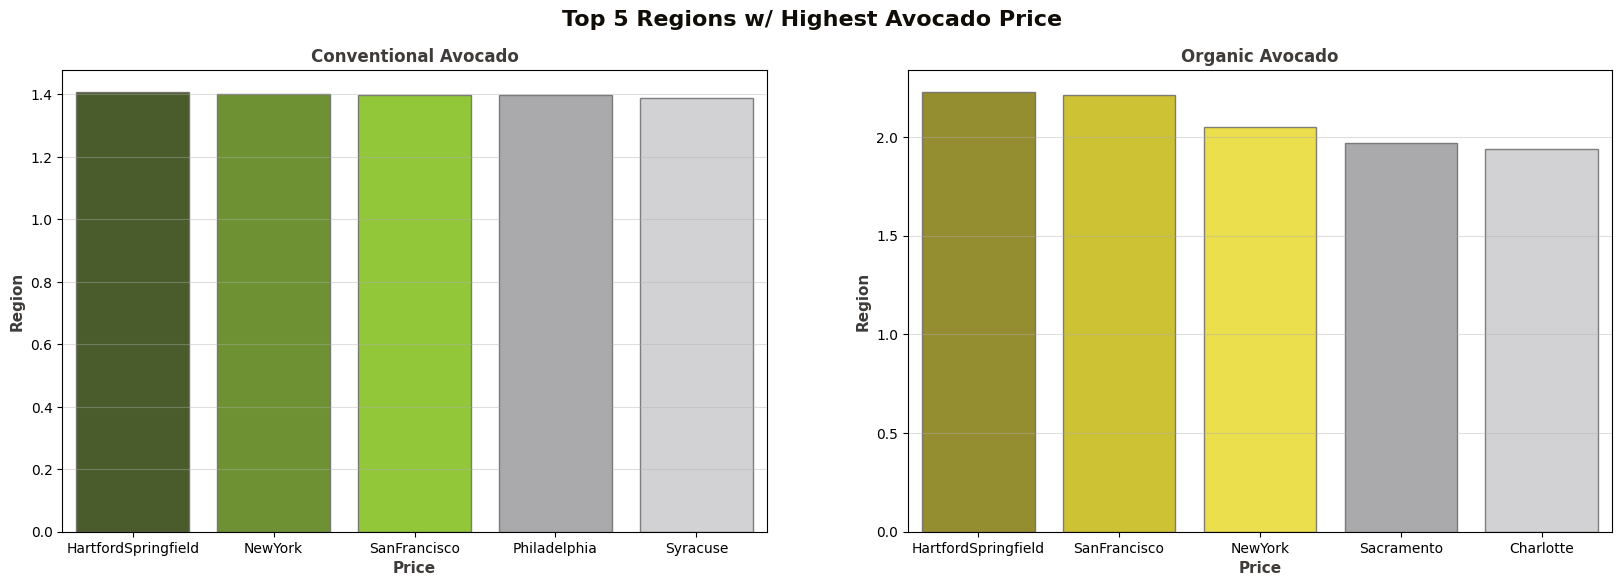

In [27]:
# --- Create New Dataframes based on Type ---
eda2 = ds[['region', 'AveragePrice']][ds.type == 'conventional']
eda2 = eda2.groupby(['region']).aggregate({'AveragePrice': np.mean}).sort_values(by = 'AveragePrice',
                                                                                 ascending = False).iloc[:5]

eda3 = ds[['region', 'AveragePrice']][ds.type == 'organic']
eda3 = eda3.groupby(['region']).aggregate({'AveragePrice': np.mean}).sort_values(by = 'AveragePrice',
                                                                                 ascending = False).iloc[:5]

# --- General Settings of Bar Charts ---
fig, ax = plt.subplots(1, 2, figsize = (20, 6))
fig.suptitle('Top 5 Regions w/ Highest Avocado Price', fontweight = 'heavy', fontsize = 16, fontfamily = 'sans-serif',
             color = black_grad[0])

# --- Bar Chart Left ---
plt.subplot(1, 2, 1)
plt.title('Conventional Avocado', fontweight = 'bold', fontsize = 12, fontfamily = 'sans-serif', color = black_grad[1])
bar_left = sns.barplot(y = 'AveragePrice', x = eda2.index, data = eda2, palette = black_grad, edgecolor = black_grad[2],
                       alpha = 0.85)
bar_left.patches[0].set_facecolor(olive_grad[0])
bar_left.patches[1].set_facecolor(olive_grad[1])
bar_left.patches[2].set_facecolor(olive_grad[2])
plt.xlabel('Price', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Region', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
plt.grid(axis = 'x', alpha = 0)
plt.ticklabel_format(style = 'plain', axis = 'y')

# --- Bar Chart Right ---
plt.subplot(1, 2, 2)
plt.title('Organic Avocado', fontweight = 'bold', fontsize = '12', fontfamily = 'sans-serif', color = black_grad[1])
bar_right = sns.barplot(y='AveragePrice', x = eda3.index, data = eda3, palette = black_grad, edgecolor = black_grad[2],
                        alpha = 0.85)
bar_right.patches[0].set_facecolor(yellow_grad[1])
bar_right.patches[1].set_facecolor(yellow_grad[2])
bar_right.patches[2].set_facecolor(yellow_grad[3])
plt.xlabel('Price', fontweight='bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Region', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
plt.grid(axis = 'x', alpha = 0)
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show();

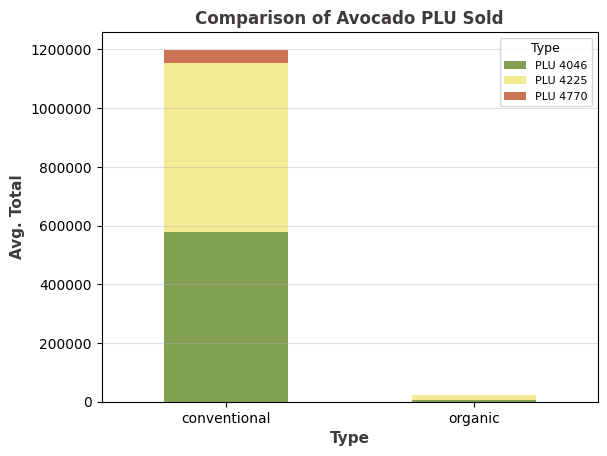

In [28]:
# --- Creating New Data Frame ---
eda30 = ds[['type', '4046', '4225', '4770']]
eda30 = eda30.groupby(['type']).aggregate({'4046': 'mean', '4225': 'mean', '4770': 'mean'})

# --- Stacked Bar Chart ---
eda30.plot(kind='bar', stacked = True, color = color_mix[-4:-1], alpha = 0.85)
plt.title('Comparison of Avocado PLU Sold', fontweight = 'bold', fontsize = '12', fontfamily = 'sans-serif',
          color = black_grad[1])
plt.xlabel('Type', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Avg. Total', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
plt.grid(axis = 'x', alpha = 0)
plt.legend(labels = ['PLU 4046','PLU 4225', 'PLU 4770'], title = 'Type', fontsize = '8', title_fontsize = '9',
           loc = 'upper right', frameon = True)
plt.xticks(rotation = 0)
plt.ticklabel_format(style = 'plain', axis = 'y');

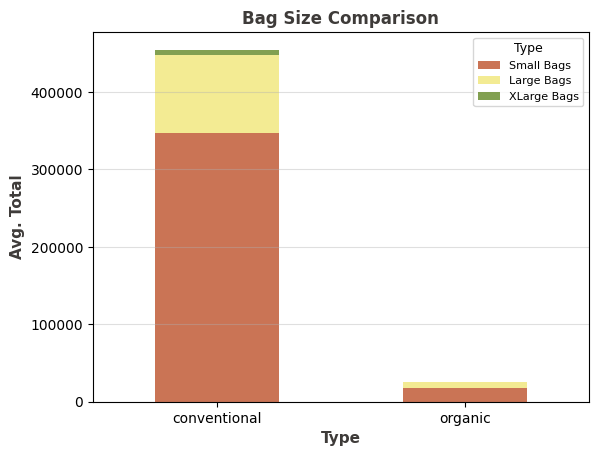

In [29]:
# --- Creating New Data Frame ---
eda31 = ds[['type', 'Small Bags', 'Large Bags', 'XLarge Bags']]
eda31 = eda31.groupby(['type']).aggregate({'Small Bags': 'mean', 'Large Bags': 'mean', 'XLarge Bags': 'mean'})

# --- Stacked Bar Chart ---
eda31.plot(kind = 'bar', stacked = True, color = color_mix[3:0:-1], alpha = 0.85)
plt.title('Bag Size Comparison', fontweight = 'bold', fontsize = 12, fontfamily = 'sans-serif', color = black_grad[1])
plt.xlabel('Type', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Avg. Total', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
plt.grid(axis = 'x', alpha = 0)
plt.legend(labels = ['Small Bags','Large Bags', 'XLarge Bags'], title = 'Type', fontsize = 8, title_fontsize = 9,
           loc = 'upper right', frameon = True)
plt.xticks(rotation = 0)
plt.ticklabel_format(style = 'plain', axis = 'y');

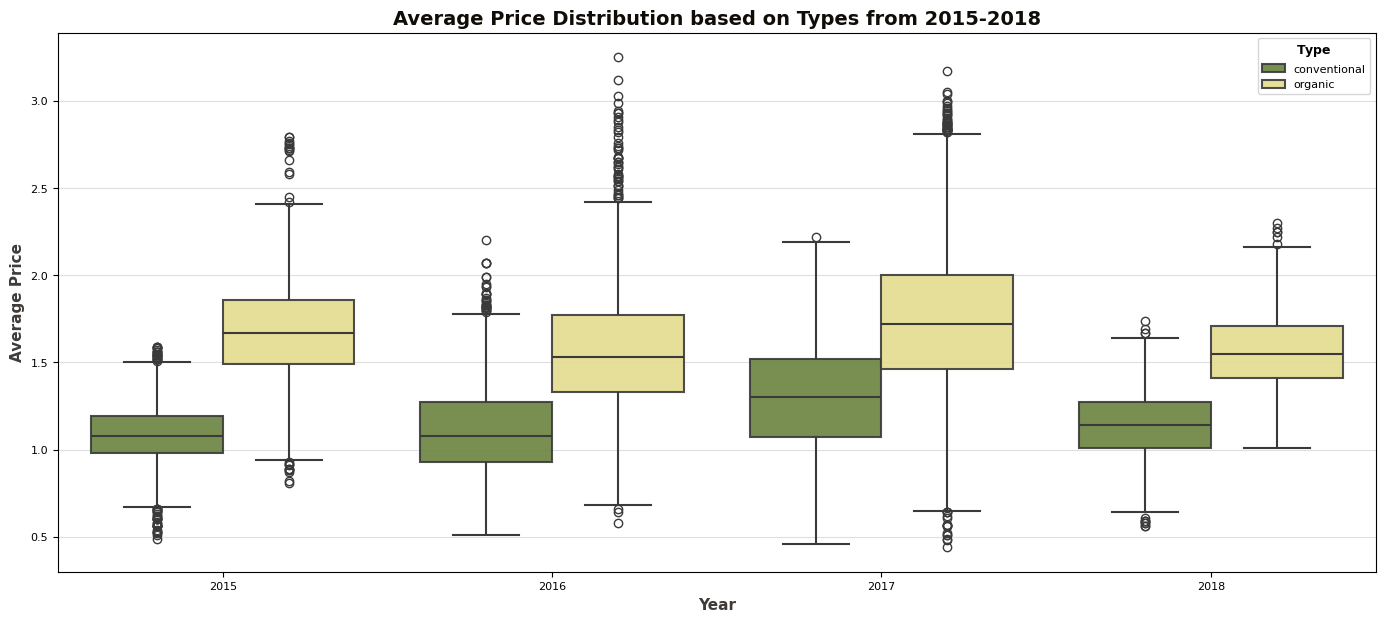

In [30]:
# --- Creating Box Plot based on Type ---
fig, ax = plt.subplots()
fig.set_size_inches(17, 7)
plt.title('Average Price Distribution based on Types from 2015-2018', fontweight='bold', fontsize = 14,
          fontfamily = 'sans-serif', color = black_grad[0])
sns.boxplot(x = 'year', y = 'AveragePrice', hue = 'type', data = ds, ax = ax, palette = color_mix[1:3],
            boxprops = dict(alpha = 0.9), linewidth = 1.5)
plt.xlabel('Year', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Average Price', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.legend(title = '$\\bf{Type}$', fontsize = 8, title_fontsize = 9, loc = 'upper right', frameon = True)
plt.grid(axis = 'y', alpha = 0.4)
plt.show()

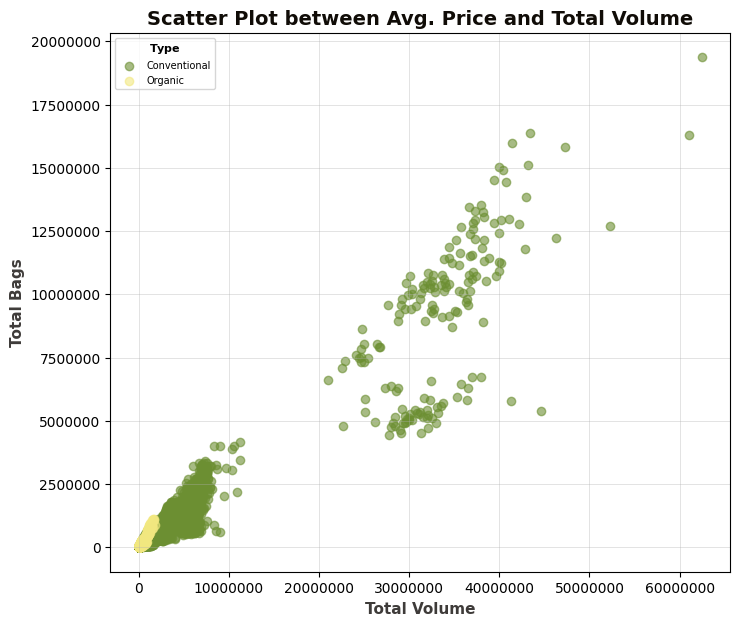

In [31]:
# --- Seperating Total Volume & Total Bags based on Type ---
x0 = ds.xs('Total Volume', axis = 1)[ds.type == 'conventional']
x1 = ds.xs('Total Volume', axis = 1)[ds.type == 'organic']
y0 = ds.xs('Total Bags', axis = 1)[ds.type == 'conventional']
y1 = ds.xs('Total Bags', axis = 1)[ds.type == 'organic']

# --- Creating Scatter Plot ---
plt.figure(figsize = (8, 7))
plt.title('Scatter Plot between Avg. Price and Total Volume', fontweight = 'bold', fontsize = 14,
          fontfamily = 'sans-serif', color = black_grad[0])
plt.scatter(x = x0, y = y0, c = color_mix[1], alpha = 0.6, linewidths = 1)
plt.scatter(x = x1, y = y1, c = color_mix[2], alpha = 0.6, linewidths = 1)
plt.legend(['Conventional', 'Organic'], title = '$\\bf{Type}$', fontsize = 7, title_fontsize = 8, loc = 'upper left',
           frameon = True)
plt.xlabel('Total Volume', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total Bags', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ticklabel_format(style = 'plain', axis = 'both')
plt.grid(axis = 'both', alpha = 0.5, lw = 0.5)
plt.show()

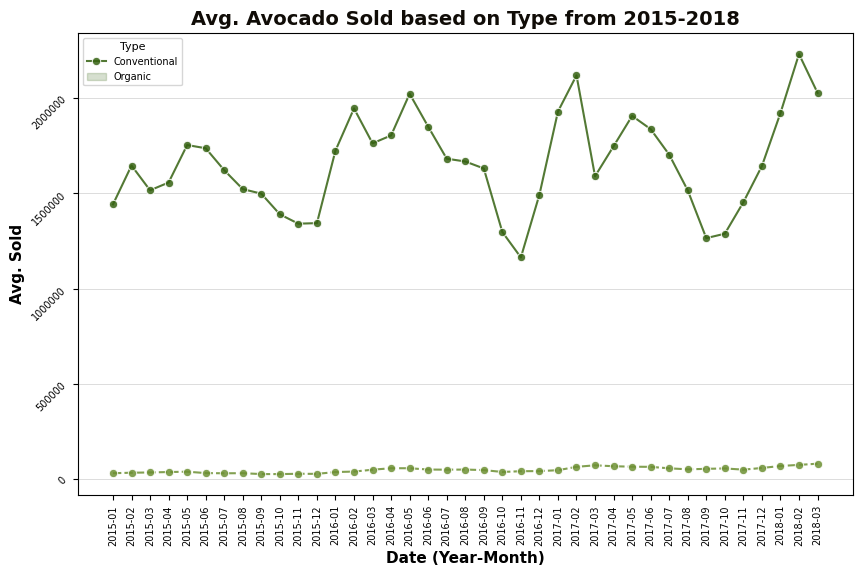

In [32]:
# --- Calculating Mean of `Total Volume` grouped by Type and Date ---
dseda8 = ds[['Date', 'Total Volume', 'type']].copy()
dseda8['Date'] = pd.DatetimeIndex(dseda8['Date'])
dseda8['Date'] = dseda8['Date'].apply(lambda x: x.strftime('%Y-%m'))
group8 = dseda8.groupby(['Date', 'type'])
mnth_avg8 = group8.aggregate({'Total Volume': 'mean'})

# --- Creating Time Series Plot of Avg. Price ---
plt.figure(figsize = (10, 6))
plt.title('Avg. Avocado Sold based on Type from 2015-2018', fontweight = 'bold', fontsize = 14,
          fontfamily = 'sans-serif', color = black_grad[0])
sns.lineplot(data = mnth_avg8, x = 'Date', y = 'Total Volume', hue = 'type', style = 'type', markers = ['o', 'o'],
             palette = color_mix[0:2], alpha = 0.85)
plt.xlabel('Date (Year-Month)', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ylabel('Avg. Sold', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation = 90, fontsize = 7)
plt.yticks(rotation = 45, fontsize = 7)
plt.grid(axis='y', alpha = 0.5, lw = 0.6)
plt.grid(axis='x', alpha = 0)
plt.legend(labels = ['Conventional', 'Organic'], title = 'Type', fontsize = 7, title_fontsize = 8, frameon=True);

/tmp/ipykernel_23003/1039062435.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dseda9['Date'] = pd.DatetimeIndex(dseda9['Date'])
/tmp/ipykernel_23003/1039062435.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dseda9['Date'] = dseda9['Date'].apply(lambda x: x.strftime('%Y-%m'))
/tmp/ipykernel_23003/1039062435.py:6: FutureWarning: The provided callable <function mean at 0x7cef045f9760> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. T

ValueError: rotation must be 'vertical', 'horizontal' or a number, not 90

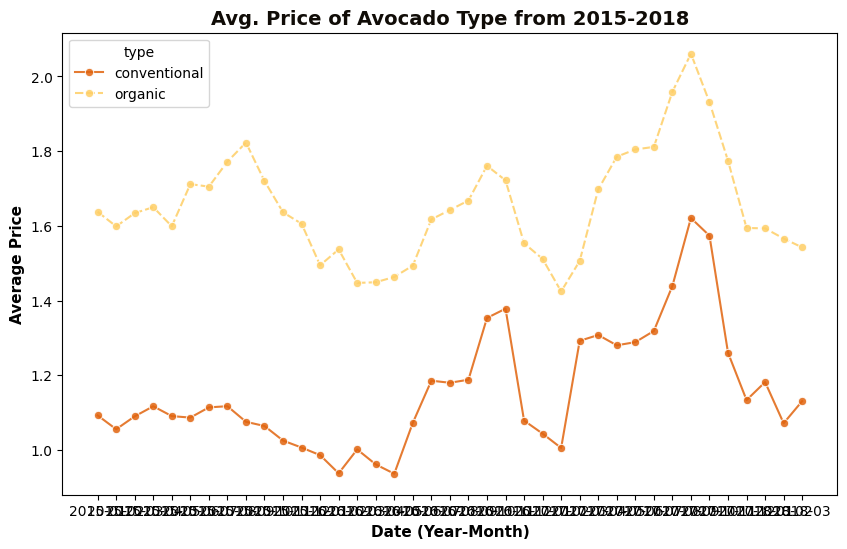

In [33]:
# --- Calculating Mean of `AveragePrice` grouped by Type and Date ---
dseda9 = ds[['Date', 'AveragePrice', 'type']]
dseda9['Date'] = pd.DatetimeIndex(dseda9['Date'])
dseda9['Date'] = dseda9['Date'].apply(lambda x: x.strftime('%Y-%m'))
group9 = dseda9.groupby(['Date', 'type'])
mnth_avg9 = group9.aggregate({'AveragePrice': np.mean})

# --- Creating Time Series Plot of Avg. Price ---
plt.figure(figsize = (10, 6))
plt.title('Avg. Price of Avocado Type from 2015-2018', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif',
          color = black_grad[0])
sns.lineplot(data = mnth_avg9, x = 'Date', y = 'AveragePrice', hue = 'type', style = 'type', markers = ['o', 'o'],
             palette = 'YlOrBr_r', alpha = 0.85)
plt.xlabel('Date (Year-Month)', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ylabel('Average Price', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.xticks(rotation = '90', fontsize = 7)
plt.yticks(fontsize = 7)
plt.grid(axis = 'y', alpha = 0.5, lw = 0.6)
plt.grid(axis = 'x', alpha = 0)
plt.legend(labels = ['Conventional', 'Organic'], title = '$\\bf{Type}$', fontsize = 7, title_fontsize = 8,
           loc = 'upper left', frameon = True);

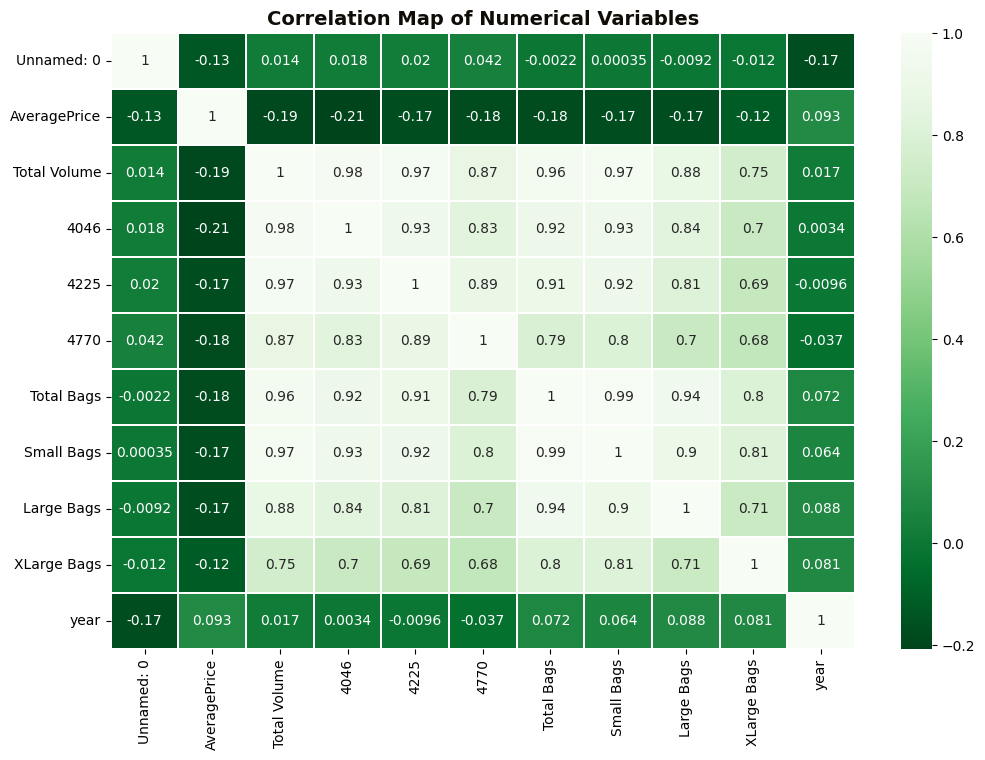

In [34]:
# --- Correlation Map (Heatmap) ---
plt.figure(figsize = (12, 8))
# Select only numerical columns for correlation calculation
numeric_ds = ds.select_dtypes(include=np.number)
sns.heatmap(numeric_ds.corr(), annot = True, cmap = 'Greens_r', linewidths = 0.1)
plt.title('Correlation Map of Numerical Variables', fontsize = 14, fontweight = 'bold', fontfamily = 'sans-serif',
          color = black_grad[0]);


In [35]:
# --- Change `Date` Format to 'datetime' ---
import pandas as pd
ds.Date = pd.to_datetime(ds.Date)

# --- Extracting Month Number from `Date`  ---
ds['month'] = pd.DatetimeIndex(ds['Date']).month

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/tmp/ipykernel_23003/3725056276.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_lgbm[indices_lgbm], y=np.array(all_features)[indices_lgbm],


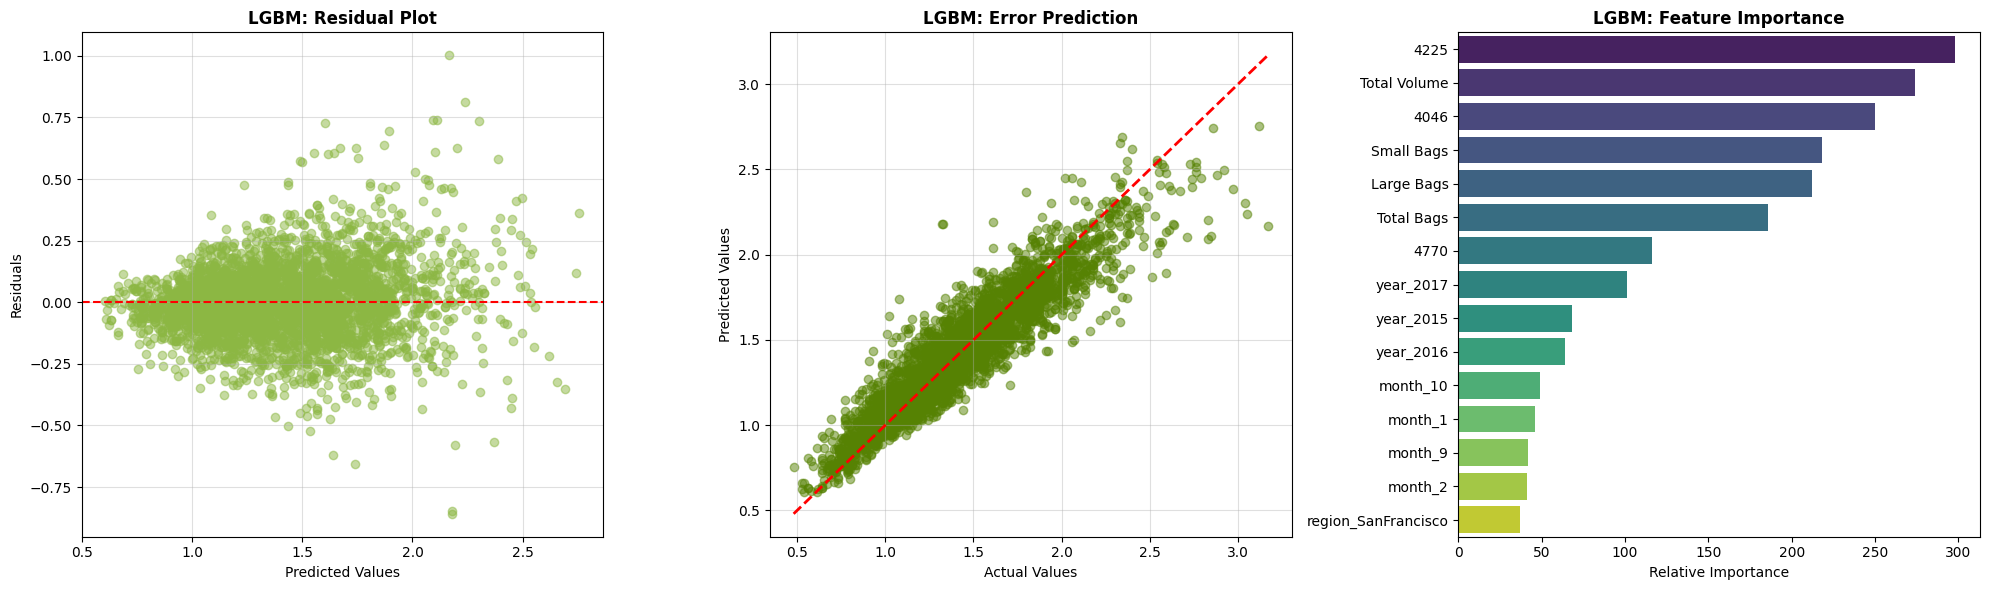

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 아까 만들어둔 파이프라인에서 LightGBM 모델 꺼내기
lgbm_pipeline = trained_models['Light Gradient Boosting Machine']
lgbm_model = lgbm_pipeline.named_steps['model']

# 테스트 데이터 예측
y_test_pred_lgbm = lgbm_pipeline.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Residual Plot (잔차도)
residuals_lgbm = y_test - y_test_pred_lgbm
axes[0].scatter(y_test_pred_lgbm, residuals_lgbm, alpha=0.5, color='#8CB743')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('LGBM: Residual Plot', fontweight='bold')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].grid(alpha=0.4)

# 2. Error Prediction Plot (예측 오차도)
axes[1].scatter(y_test, y_test_pred_lgbm, alpha=0.5, color='#568203')
max_val = max(y_test.max(), y_test_pred_lgbm.max())
min_val = min(y_test.min(), y_test_pred_lgbm.min())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[1].set_title('LGBM: Error Prediction', fontweight='bold')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].grid(alpha=0.4)

# 3. Feature Importance Plot (특성 중요도)
importances_lgbm = lgbm_model.feature_importances_
indices_lgbm = np.argsort(importances_lgbm)[::-1][:15] # 상위 15개
sns.barplot(x=importances_lgbm[indices_lgbm], y=np.array(all_features)[indices_lgbm],
            palette='viridis', ax=axes[2])
axes[2].set_title('LGBM: Feature Importance', fontweight='bold')
axes[2].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

In [51]:
from sklearn.model_selection import RandomizedSearchCV

print('\033[92m\033[1m'+'.: LightGBM 하이퍼파라미터 튜닝 시작 :.'+'\033[0m')

# 탐색할 파라미터 공간 정의 (pipeline 내부의 model 파라미터이므로 'model__' 접두사 사용)
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [31, 50, 100],
    'model__max_depth': [-1, 10, 20]
}

# 랜덤 서치 설정 (시간 절약을 위해 n_iter=5 로 설정)
lgbm_random = RandomizedSearchCV(lgbm_pipeline, param_distributions=param_dist,
                                 n_iter=5, cv=3, scoring='r2', random_state=123, n_jobs=-1)

# 튜닝 진행
lgbm_random.fit(X_train, y_train)

# 튜닝된 최고 모델 저장
tuned_lgbm_pipeline = lgbm_random.best_estimator_

print(f"최적 파라미터: {lgbm_random.best_params_}")
print(f"튜닝 후 Test R2 Score: {tuned_lgbm_pipeline.score(X_test, y_test):.4f}")
print('\033[92m'+'*' * 40+'\033[0m')

.: LightGBM 하이퍼파라미터 튜닝 시작 :.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002035 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2184
[LightGBM] [Info] Number of data points in the train set: 14599, number of used features: 80
[LightGBM] [Info] Start training from score 1.405350
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
최적 파라미터: {'model__num_leaves': 100, 'model__n_estimators': 300, 'model__max_depth': 20, 'model__learning_rate': 0.1}
튜닝 후 Test R2 Score: 0.9209
***********************************

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [52]:
# 1. Best Model (Extra Tree) 예측
pred_best = best_pipeline.predict(X_test)

# 2. Random Forest 예측
pred_rf = trained_models['Random Forest Regressor'].predict(X_test)

# 3. LightGBM 예측 (튜닝 전)
pred_lgbm = trained_models['Light Gradient Boosting Machine'].predict(X_test)

# 데이터프레임으로 결과 살짝 구경해보기
predictions_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Best_Pred(ET)': pred_best,
    'RF_Pred': pred_rf,
    'LGBM_Pred': pred_lgbm
})
display(predictions_df.head(10))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Actual Price,Best_Pred(ET),RF_Pred,LGBM_Pred
0,0.82,0.8531,0.8498,0.915068
1,1.61,1.6236,1.6275,1.579547
2,1.68,1.6048,1.6175,1.500450
3,1.01,1.0157,1.0399,1.052407
4,0.92,1.3567,1.3948,1.229228
5,1.04,0.9289,0.9457,0.933279
6,1.89,1.8423,1.8814,1.774115
7,1.19,1.2171,1.2100,1.158201
8,1.80,1.5662,1.3933,1.446175
9,1.53,1.5716,1.6319,1.670017


In [53]:
import joblib

print('\033[92m\033[1m'+'.: Best Model Finalize (전체 데이터 재학습) 및 저장 :.'+'\033[0m')

# 1. Finalize: 아까 찾은 Best Model(Extra Tree)을 전체 데이터(X, y)로 다시 학습
final_best_pipeline = best_pipeline.fit(X, y)
print("전체 데이터(X, y)로 최종 학습 완료!")

# 2. Save Model: pickle/joblib 파일로 저장
save_path = 'Final_Best_Model_caesarmario_06May2022.pkl'
joblib.dump(final_best_pipeline, save_path)

print(f"⭐ 모델 저장 완료: {save_path} ⭐")
print('\033[92m'+'*' * 50+'\033[0m')

.: Best Model Finalize (전체 데이터 재학습) 및 저장 :.
전체 데이터(X, y)로 최종 학습 완료!
⭐ 모델 저장 완료: Final_Best_Model_caesarmario_06May2022.pkl ⭐
**************************************************
